In [6]:
import os
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy.stats import entropy as scipy_entropy
from scipy.interpolate import interp1d
from collections import defaultdict

# from generate_space_zv2 import compute_confusion_matrix_and_entropy_from_embeddings_folder

embeddings_dir = "embeddings_all"

from vis_data import add_to_viewer
import napari
from validation_zslices import compute_confusion_matrix_and_entropy_from_embeddings_folder


In [7]:
def load_entropy_metrics(metrics_path):
    """Load entropy metrics from JSON file"""
    with open(metrics_path, 'r') as f:
        metrics = json.load(f)
    return metrics

def plot_spatial_entropy(metrics, embeddings_dir=None, save_path=None):
    """
    Plot spatial entropy (between embeddings) - entropy in embedding space.
    Shows entropy distribution across different drugs/conditions.
    """
    knn_entropies = metrics['knn_entropy_per_embedding']
    drug_names = metrics['drug_name_list']
    
    # Group entropies by drug
    drug_entropy_dict = defaultdict(list)
    for ent, drug in zip(knn_entropies, drug_names):
        drug_entropy_dict[drug].append(ent)
    
    # Create plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Box plot by drug
    drugs = sorted(drug_entropy_dict.keys())
    entropy_lists = [drug_entropy_dict[drug] for drug in drugs]
    
    bp = axes[0].boxplot(entropy_lists, labels=drugs, patch_artist=True)
    axes[0].set_xlabel('Drug/Condition', fontsize=12)
    axes[0].set_ylabel('Spatial Entropy (bits)', fontsize=12)
    axes[0].set_title('Spatial Entropy Distribution by Drug', fontsize=14)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3)
    
    # Color the boxes
    colors = plt.cm.Set3(np.linspace(0, 1, len(bp['boxes'])))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    # Plot 2: Histogram of all entropies
    axes[1].hist(knn_entropies, bins=50, edgecolor='black', alpha=0.7)
    axes[1].axvline(np.mean(knn_entropies), color='red', linestyle='--', 
                    label=f'Mean: {np.mean(knn_entropies):.3f}')
    axes[1].set_xlabel('Spatial Entropy (bits)', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].set_title('Spatial Entropy Distribution (All Embeddings)', fontsize=14)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved spatial entropy plot to {save_path}")
    
    plt.show()
    
    # Print statistics
    print(f"\nSpatial Entropy Statistics:")
    print(f"  Mean: {np.mean(knn_entropies):.4f} bits")
    print(f"  Std: {np.std(knn_entropies):.4f} bits")
    print(f"  Min: {np.min(knn_entropies):.4f} bits")
    print(f"  Max: {np.max(knn_entropies):.4f} bits")
    print(f"\nMean entropy by drug:")
    for drug in drugs:
        mean_ent = np.mean(drug_entropy_dict[drug])
        print(f"  {drug}: {mean_ent:.4f} bits")
    
    return fig

In [8]:
def compute_temporal_entropy_in_embedding_space(embedding_data, method='dimension_distribution'):
    """
    Compute temporal entropy in embedding space for a single embedding file.
    
    Args:
        embedding_data: numpy array of shape (n_embeddings, embedding_dim)
                        e.g., (60, 768) - 60 embeddings with 768 dimensions each
        method: 'dimension_distribution' - compute entropy across embedding dimensions
                for each embedding position
    
    Returns:
        temporal_entropies: array of entropy values for each embedding position (length n_embeddings)
    """
    n_embeddings, embedding_dim = embedding_data.shape
    
    temporal_entropies = []
    
    for i in range(n_embeddings):
        # Get embedding at position i: shape (embedding_dim,)
        embedding = embedding_data[i, :]
        
        if method == 'dimension_distribution':
            # Normalize embedding values to create probability distribution
            # Shift to non-negative values
            embedding_shifted = embedding - embedding.min()
            # Normalize to sum to 1 (probability distribution)
            embedding_norm = embedding_shifted / (embedding_shifted.sum() + 1e-8)
            # Compute entropy across embedding dimensions
            ent = scipy_entropy(embedding_norm, base=2)
            
        elif method == 'histogram':
            # Create histogram of embedding dimension values
            hist, _ = np.histogram(embedding, bins=50)
            prob_dist = hist / (hist.sum() + 1e-8)
            ent = scipy_entropy(prob_dist, base=2)
        
        temporal_entropies.append(ent)
    
    return np.array(temporal_entropies)

def plot_temporal_entropy_in_embedding_space(embeddings_dir, save_path=None, max_files=20):
    """
    Plot temporal entropy in embedding space - entropy across embedding dimensions 
    for each embedding position (e.g., 60 positions per file).
    
    Args:
        embeddings_dir: directory containing embedding files (shape: n_embeddings, embedding_dim)
        save_path: path to save the plot
        max_files: maximum number of embedding files to process (for visualization)
    """
    import os.path as osp
    
    # Get all embedding files
    embedding_files = sorted([f for f in os.listdir(embeddings_dir) 
                            if f.endswith('.npy') and f.startswith('embeddings_20')])
    
    if not embedding_files:
        print(f"No embedding files found in {embeddings_dir}!")
        return None
    
    all_temporal_entropies = []
    embedding_labels = []
    
    print(f"Computing temporal entropy in embedding space for {min(len(embedding_files), max_files)} files...")
    for fname in embedding_files[:max_files]:
        try:
            embedding_path = osp.join(embeddings_dir, fname)
            embedding_data = np.load(embedding_path)
            
            # Check shape: should be (n_embeddings, embedding_dim)
            if embedding_data.ndim != 2:
                print(f"Skipping {fname}: expected 2D array, got shape {embedding_data.shape}")
                continue
            
            n_embeddings, embedding_dim = embedding_data.shape
            print(f"  Processing {fname}: shape ({n_embeddings}, {embedding_dim})")
            
            # Compute temporal entropy for this embedding file
            temporal_ent = compute_temporal_entropy_in_embedding_space(embedding_data)
            all_temporal_entropies.append(temporal_ent)
            
            # Create label from filename
            embedding_labels.append(fname.replace('.npy', ''))
            
        except Exception as e:
            print(f"Error loading {fname}: {e}")
            continue
    
    if not all_temporal_entropies:
        print("No valid embedding files found!")
        return None
    
    # Create plot
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot 1: Temporal entropy over embedding position for each file
    n_positions = len(all_temporal_entropies[0])  # Should be 60
    position_axis = np.arange(n_positions)
    
    for i, (temporal_ent, label) in enumerate(zip(all_temporal_entropies, embedding_labels)):
        axes[0].plot(position_axis, temporal_ent, alpha=0.6, 
                    label=label if i < 5 else None, linewidth=1.5)
    
    axes[0].set_xlabel('Embedding Position (e.g., time/z-slice)', fontsize=12)
    axes[0].set_ylabel('Temporal Entropy (bits)', fontsize=12)
    axes[0].set_title(f'Temporal Entropy Across Embedding Positions (Within Each File)\n({n_positions} positions per file)', fontsize=14)
    axes[0].legend(fontsize=8, loc='best')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Mean temporal entropy distribution across files
    mean_temporal_entropies = [np.mean(te) for te in all_temporal_entropies]
    axes[1].hist(mean_temporal_entropies, bins=30, edgecolor='black', alpha=0.7)
    axes[1].axvline(np.mean(mean_temporal_entropies), color='red', linestyle='--',
                    label=f'Mean: {np.mean(mean_temporal_entropies):.3f} bits')
    axes[1].set_xlabel('Mean Temporal Entropy (bits)', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].set_title('Distribution of Mean Temporal Entropy Across Embedding Files', fontsize=14)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved temporal entropy plot to {save_path}")
    
    plt.show()
    
    # Print statistics
    print(f"\nTemporal Entropy Statistics (in embedding space):")
    print(f"  Number of files processed: {len(all_temporal_entropies)}")
    print(f"  Embedding positions per file: {n_positions}")
    print(f"  Embedding dimension: {embedding_dim}")
    print(f"  Mean entropy (across all positions and files): {np.mean([np.mean(te) for te in all_temporal_entropies]):.4f} bits")
    print(f"  Std (across files): {np.std([np.mean(te) for te in all_temporal_entropies]):.4f} bits")
    print(f"  Min mean entropy: {np.min(mean_temporal_entropies):.4f} bits")
    print(f"  Max mean entropy: {np.max(mean_temporal_entropies):.4f} bits")
    
    return fig, all_temporal_entropies

In [9]:
def compute_entropy_in_time_direction(image_data, method='pixel_distribution'):
    """
    Compute entropy in the time direction for a 4D image.
    For each z-slice, compute entropy across time points.
    
    Args:
        image_data: numpy array of shape (time_points, channels, z_slices, y_dim, x_dim)
        method: 'pixel_distribution' or 'intensity_histogram'
    
    Returns:
        time_entropies: array of shape (z_slices,) - entropy for each z-slice across time
    """
    if image_data.ndim == 5 and image_data.shape[0] == 2:
        image_data = image_data.transpose(1, 0, 2, 3, 4)
    time_points, num_channels, z_slices, y_dim, x_dim = image_data.shape
    
    time_entropies = []
    
    for z in range(z_slices):
        # Get all time points for this z-slice: shape (time_points, channels, y_dim, x_dim)
        z_slice_data = image_data[:, :, z, :, :]
        
        if method == 'pixel_distribution':
            # Flatten across channels, y, x dimensions for each time point
            # Shape: (time_points, channels * y_dim * x_dim)
            flattened = z_slice_data.reshape(time_points, -1)
            
            # For each time point, create a probability distribution
            time_entropy_values = []
            for t in range(time_points):
                pixels = flattened[t, :]
                # Normalize to [0, 1]
                pixels_norm = (pixels - pixels.min()) / (pixels.max() - pixels.min() + 1e-8)
                hist, _ = np.histogram(pixels_norm, bins=50, range=(0, 1))
                prob_dist = hist / (hist.sum() + 1e-8)
                ent = scipy_entropy(prob_dist, base=2)
                time_entropy_values.append(ent)
            
            # Average entropy across time points for this z-slice
            avg_entropy = np.mean(time_entropy_values)
            
        elif method == 'intensity_histogram':
            # Create histogram across all time points for this z-slice
            pixels = z_slice_data.flatten()
            hist, _ = np.histogram(pixels, bins=50)
            prob_dist = hist / (hist.sum() + 1e-8)
            avg_entropy = scipy_entropy(prob_dist, base=2)
        
        time_entropies.append(avg_entropy)
    
    return np.array(time_entropies)

In [10]:
def compute_entropy_in_z_direction(image_data, method='pixel_distribution'):
    """
    Compute entropy in the z-direction for a 4D image.
    For each time point, compute entropy across z-slices.
    
    Args:
        image_data: numpy array of shape (time_points, channels, z_slices, y_dim, x_dim)
        method: 'pixel_distribution' or 'intensity_histogram'
    
    Returns:
        z_entropies: array of shape (time_points,) - entropy for each time point across z-slices
    """
    time_points, num_channels, z_slices, y_dim, x_dim = image_data.shape
    
    z_entropies = []
    
    for t in range(time_points):
        # Get all z-slices for this time point: shape (channels, z_slices, y_dim, x_dim)
        time_slice_data = image_data[t, :, :, :, :]
        
        if method == 'pixel_distribution':
            # Flatten across channels, y, x dimensions for each z-slice
            # Shape: (z_slices, channels * y_dim * x_dim)
            flattened = time_slice_data.reshape(z_slices, -1)
            
            # For each z-slice, create a probability distribution
            z_entropy_values = []
            for z in range(z_slices):
                pixels = flattened[z, :]
                # Normalize to [0, 1]
                pixels_norm = (pixels - pixels.min()) / (pixels.max() - pixels.min() + 1e-8)
                hist, _ = np.histogram(pixels_norm, bins=50, range=(0, 1))
                prob_dist = hist / (hist.sum() + 1e-8)
                ent = scipy_entropy(prob_dist, base=2)
                z_entropy_values.append(ent)
            
            # Average entropy across z-slices for this time point
            avg_entropy = np.mean(z_entropy_values)
            
        elif method == 'intensity_histogram':
            # Create histogram across all z-slices for this time point
            pixels = time_slice_data.flatten()
            hist, _ = np.histogram(pixels, bins=50)
            prob_dist = hist / (hist.sum() + 1e-8)
            avg_entropy = scipy_entropy(prob_dist, base=2)
        
        z_entropies.append(avg_entropy)
    
    return np.array(z_entropies)

In [11]:
def compare_time_vs_z_entropy(image_data, save_path=None, method='pixel_distribution'):
    """
    Compute and compare entropy in time and z directions for a 4D image.
    
    Args:
        image_data: numpy array of shape (time_points, channels, z_slices, y_dim, x_dim)
        save_path: optional path to save the comparison plot
        method: 'pixel_distribution' or 'intensity_histogram'
    
    Returns:
        time_entropies: array of entropy values across z-slices (entropy in time direction)
        z_entropies: array of entropy values across time points (entropy in z direction)
        comparison_stats: dictionary with comparison statistics
    """
    # Handle different input shapes
    if image_data.ndim == 5:
        if image_data.shape[0] == 2:
            # Shape is (channels, time_points, z_slices, y_dim, x_dim)
            image_data = image_data.transpose(1, 0, 2, 3, 4)
        # Now shape is (time_points, channels, z_slices, y_dim, x_dim)
    else:
        raise ValueError(f"Expected 5D array, got shape {image_data.shape}")
    
    time_points, num_channels, z_slices, y_dim, x_dim = image_data.shape
    
    # Compute entropies
    time_entropies = compute_entropy_in_time_direction(image_data, method=method)
    z_entropies = compute_entropy_in_z_direction(image_data, method=method)
    
    # Create comparison plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Entropy in time direction (across z-slices)
    z_axis = np.arange(z_slices)
    axes[0, 0].plot(z_axis, time_entropies, 'b-o', linewidth=2, markersize=4)
    axes[0, 0].axhline(np.mean(time_entropies), color='red', linestyle='--', 
                      label=f'Mean: {np.mean(time_entropies):.3f} bits')
    axes[0, 0].set_xlabel('Z-Slice Index', fontsize=12)
    axes[0, 0].set_ylabel('Entropy (bits)', fontsize=12)
    axes[0, 0].set_title('Entropy in Time Direction\n(across time points for each z-slice)', fontsize=13)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Entropy in z direction (across time points)
    time_axis = np.arange(time_points)
    axes[0, 1].plot(time_axis, z_entropies, 'g-s', linewidth=2, markersize=4)
    axes[0, 1].axhline(np.mean(z_entropies), color='red', linestyle='--',
                      label=f'Mean: {np.mean(z_entropies):.3f} bits')
    axes[0, 1].set_xlabel('Time Point Index', fontsize=12)
    axes[0, 1].set_ylabel('Entropy (bits)', fontsize=12)
    axes[0, 1].set_title('Entropy in Z Direction\n(across z-slices for each time point)', fontsize=13)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Overlay comparison
    # Normalize axes for comparison
    axes[1, 0].plot(z_axis, time_entropies, 'b-o', linewidth=2, markersize=4, 
                   label='Time Direction Entropy', alpha=0.7)
    # Map z_entropies to z_axis for comparison (interpolate if needed)
    if len(z_entropies) == len(time_entropies):
        axes[1, 0].plot(z_axis, z_entropies, 'g-s', linewidth=2, markersize=4,
                       label='Z Direction Entropy', alpha=0.7)
    else:
        # Interpolate z_entropies to match z_axis length
        time_indices = np.linspace(0, len(z_axis)-1, len(z_entropies))
        from scipy.interpolate import interp1d
        f = interp1d(time_indices, z_entropies, kind='linear', 
                     bounds_error=False, fill_value='extrapolate')
        z_entropies_interp = f(z_axis)
        axes[1, 0].plot(z_axis, z_entropies_interp, 'g-s', linewidth=2, markersize=4,
                       label='Z Direction Entropy (interpolated)', alpha=0.7)
    
    axes[1, 0].set_xlabel('Index', fontsize=12)
    axes[1, 0].set_ylabel('Entropy (bits)', fontsize=12)
    axes[1, 0].set_title('Comparison: Time vs Z Direction Entropy', fontsize=13)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Distribution comparison
    axes[1, 1].hist(time_entropies, bins=20, alpha=0.6, label='Time Direction', 
                   color='blue', edgecolor='black')
    axes[1, 1].hist(z_entropies, bins=20, alpha=0.6, label='Z Direction', 
                   color='green', edgecolor='black')
    axes[1, 1].axvline(np.mean(time_entropies), color='blue', linestyle='--', linewidth=2,
                      label=f'Time Mean: {np.mean(time_entropies):.3f}')
    axes[1, 1].axvline(np.mean(z_entropies), color='green', linestyle='--', linewidth=2,
                      label=f'Z Mean: {np.mean(z_entropies):.3f}')
    axes[1, 1].set_xlabel('Entropy (bits)', fontsize=12)
    axes[1, 1].set_ylabel('Frequency', fontsize=12)
    axes[1, 1].set_title('Distribution Comparison', fontsize=13)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved comparison plot to {save_path}")
    
    plt.show()
    
    # Compute comparison statistics
    comparison_stats = {
        'time_direction': {
            'mean': float(np.mean(time_entropies)),
            'std': float(np.std(time_entropies)),
            'min': float(np.min(time_entropies)),
            'max': float(np.max(time_entropies)),
            'values': time_entropies.tolist()
        },
        'z_direction': {
            'mean': float(np.mean(z_entropies)),
            'std': float(np.std(z_entropies)),
            'min': float(np.min(z_entropies)),
            'max': float(np.max(z_entropies)),
            'values': z_entropies.tolist()
        },
        'comparison': {
            'mean_difference': float(np.mean(time_entropies) - np.mean(z_entropies)),
            'mean_ratio': float(np.mean(time_entropies) / (np.mean(z_entropies) + 1e-8)),
            'correlation': float(np.corrcoef(time_entropies[:min(len(time_entropies), len(z_entropies))], 
                                            z_entropies[:min(len(time_entropies), len(z_entropies))])[0, 1])
        }
    }
    
    # Print statistics
    print("\n" + "="*60)
    print("ENTROPY COMPARISON: Time Direction vs Z Direction")
    print("="*60)
    print(f"\nTime Direction Entropy (across z-slices):")
    print(f"  Mean: {comparison_stats['time_direction']['mean']:.4f} bits")
    print(f"  Std:  {comparison_stats['time_direction']['std']:.4f} bits")
    print(f"  Min:  {comparison_stats['time_direction']['min']:.4f} bits")
    print(f"  Max:  {comparison_stats['time_direction']['max']:.4f} bits")
    
    print(f"\nZ Direction Entropy (across time points):")
    print(f"  Mean: {comparison_stats['z_direction']['mean']:.4f} bits")
    print(f"  Std:  {comparison_stats['z_direction']['std']:.4f} bits")
    print(f"  Min:  {comparison_stats['z_direction']['min']:.4f} bits")
    print(f"  Max:  {comparison_stats['z_direction']['max']:.4f} bits")
    
    print(f"\nComparison:")
    print(f"  Mean Difference (Time - Z): {comparison_stats['comparison']['mean_difference']:.4f} bits")
    print(f"  Mean Ratio (Time / Z): {comparison_stats['comparison']['mean_ratio']:.4f}")
    print(f"  Correlation: {comparison_stats['comparison']['correlation']:.4f}")
    print("="*60 + "\n")
    
    return time_entropies, z_entropies, comparison_stats

Loaded image with shape: (2, 20, 60, 256, 256)
Saved comparison plot to time_vs_z_entropy_comparison.png


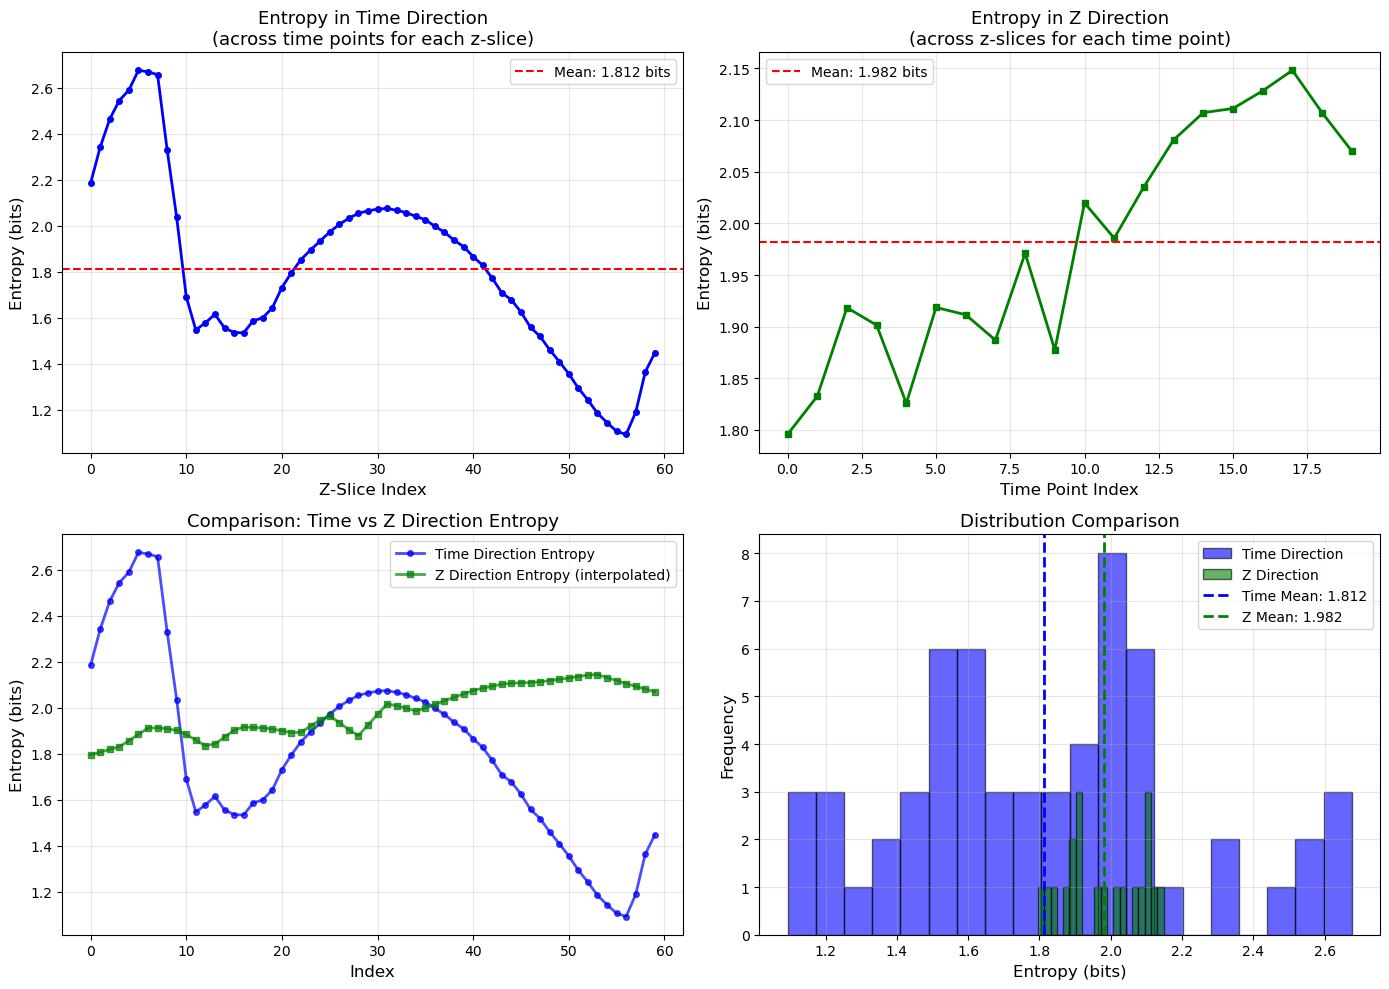


ENTROPY COMPARISON: Time Direction vs Z Direction

Time Direction Entropy (across z-slices):
  Mean: 1.8124 bits
  Std:  0.4003 bits
  Min:  1.0931 bits
  Max:  2.6762 bits

Z Direction Entropy (across time points):
  Mean: 1.9817 bits
  Std:  0.1095 bits
  Min:  1.7957 bits
  Max:  2.1481 bits

Comparison:
  Mean Difference (Time - Z): -0.1692 bits
  Mean Ratio (Time / Z): 0.9146
  Correlation: -0.8189



In [ ]:
# Example usage for 4D image entropy analysis:
# Load a 4D image and compare time vs z direction entropy

import os.path as osp

# Example: Load a 4D image file
image_path = "/run/user/1004/gvfs/smb-share:server=jslab-server1.local,share=ssd_processing/Others/MitoSpace4D/2024v2_data/processed_data/20240730-1/000500-0.npy"

if osp.exists(image_path):
    image_data = np.load(image_path)
    print(f"Loaded image with shape: {image_data.shape}")
    
    # Compare time vs z direction entropy
    time_ent, z_ent, stats = compare_time_vs_z_entropy(
        image_data, 
        save_path="time_vs_z_entropy_comparison.png",
        method='pixel_distribution'
    )
else:
    print(f"Image file not found: {image_path}")
    print("Please update the image_path variable with a valid path to a 4D .npy image file")

Saved spatial entropy plot to spatial_entropy_plot.png


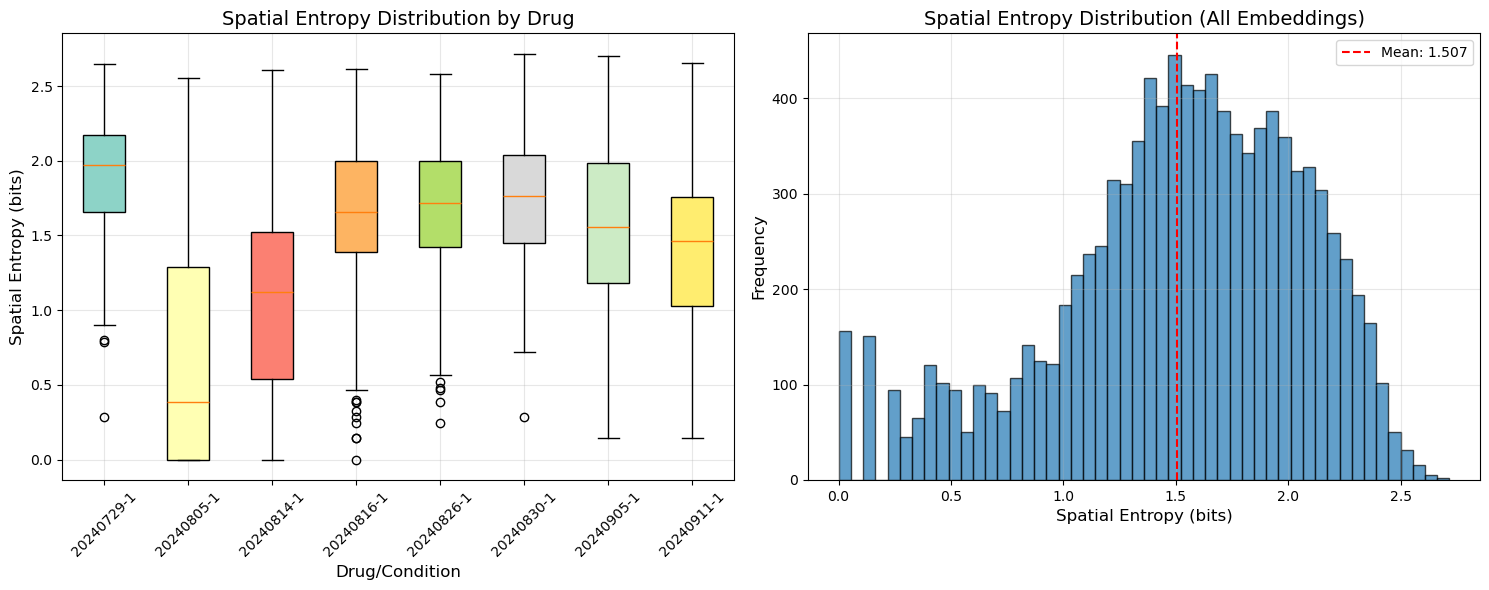


Spatial Entropy Statistics:
  Mean: 1.5068 bits
  Std: 0.5632 bits
  Min: 0.0000 bits
  Max: 2.7171 bits

Mean entropy by drug:
  20240729-1: 1.8992 bits
  20240805-1: 0.6966 bits
  20240814-1: 1.0700 bits
  20240816-1: 1.6694 bits
  20240826-1: 1.7019 bits
  20240830-1: 1.7461 bits
  20240905-1: 1.5642 bits
  20240911-1: 1.3891 bits
Computing temporal entropy in embedding space for 20 files...
  Processing embeddings_20240730-1_000500-0.npy: shape (60, 768)
  Processing embeddings_20240730-1_000501-0.npy: shape (60, 768)
  Processing embeddings_20240730-1_000502-0.npy: shape (60, 768)
  Processing embeddings_20240730-1_000503-0.npy: shape (60, 768)
  Processing embeddings_20240730-1_000504-0.npy: shape (60, 768)
  Processing embeddings_20240730-1_000505-0.npy: shape (60, 768)
  Processing embeddings_20240730-1_000506-0.npy: shape (60, 768)
  Processing embeddings_20240730-1_000507-0.npy: shape (60, 768)
  Processing embeddings_20240730-1_000508-0.npy: shape (60, 768)
  Processing emb

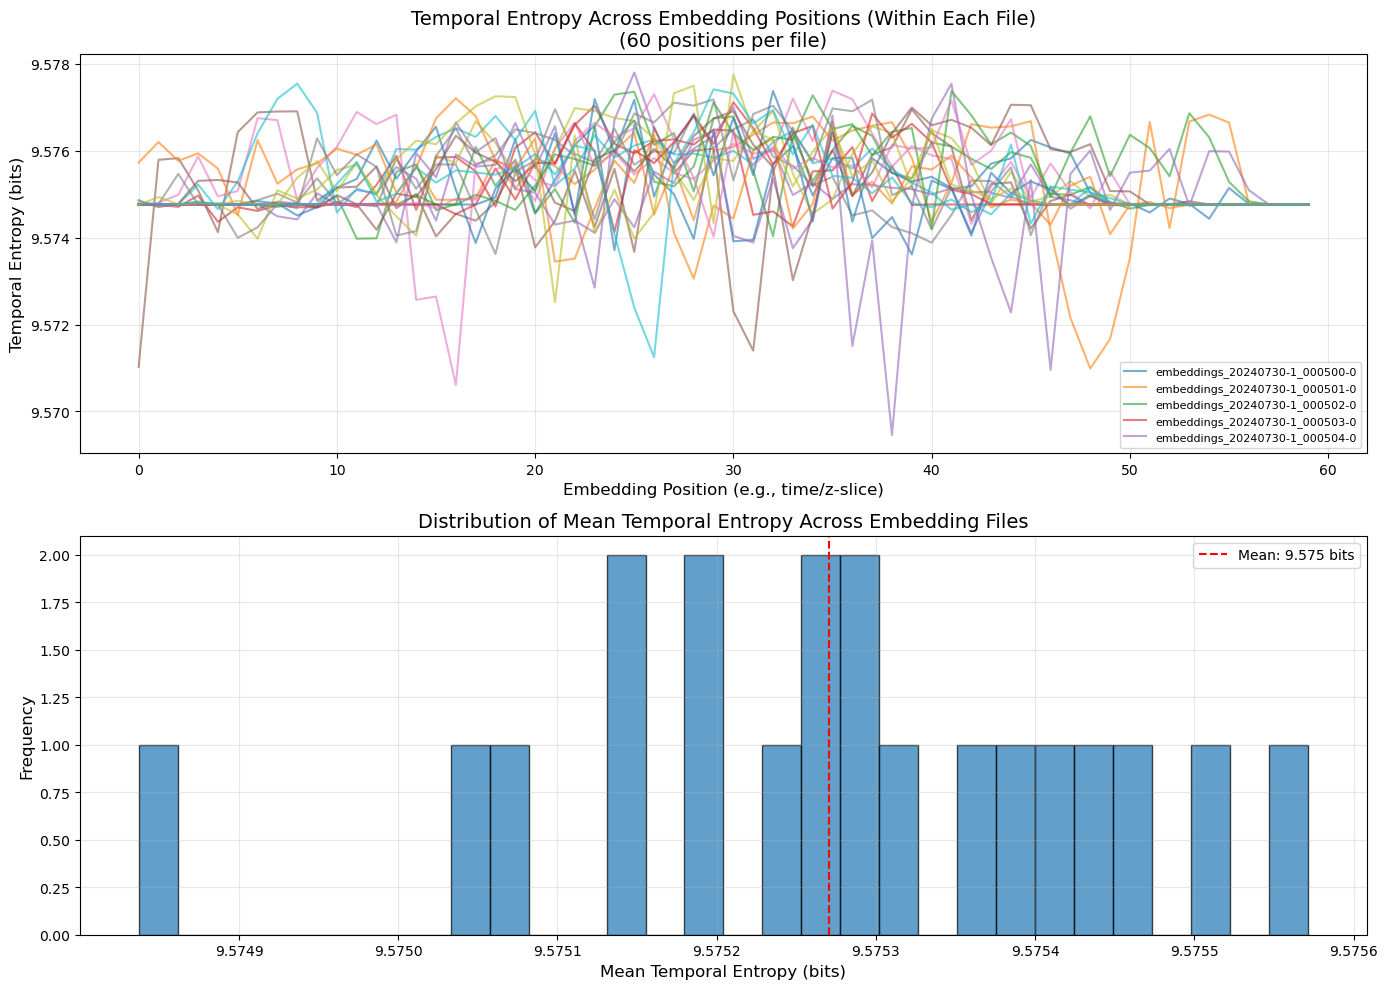


Temporal Entropy Statistics (in embedding space):
  Number of files processed: 20
  Embedding positions per file: 60
  Embedding dimension: 768
  Mean entropy (across all positions and files): 9.5753 bits
  Std (across files): 0.0002 bits
  Min mean entropy: 9.5748 bits
  Max mean entropy: 9.5756 bits


(<Figure size 1400x1000 with 2 Axes>,
 [array([9.57476536, 9.57476536, 9.57476536, 9.57476536, 9.57476536,
         9.57476536, 9.57476536, 9.57476536, 9.57476536, 9.57476536,
         9.57476536, 9.57475985, 9.57476536, 9.57476536, 9.57476123,
         9.57476536, 9.57476536, 9.57476192, 9.57493046, 9.5762678 ,
         9.57456586, 9.57533152, 9.57613571, 9.57658287, 9.57371145,
         9.576598  , 9.57545397, 9.575002  , 9.57397286, 9.57646867,
         9.57391783, 9.57394809, 9.57569131, 9.57610682, 9.57497036,
         9.57583302, 9.5758399 , 9.57399075, 9.57447505, 9.57361376,
         9.57531639, 9.57511482, 9.57518499, 9.57570507, 9.57582546,
         9.57624991, 9.57607724, 9.5759369 , 9.5750364 , 9.57477774,
         9.57478875, 9.57458099, 9.57490088, 9.57477774, 9.57443721,
         9.57514372, 9.57477636, 9.57476536, 9.57476536, 9.57476536]),
  array([9.57476536, 9.57476536, 9.57476536, 9.57476536, 9.57476536,
         9.57476536, 9.57476536, 9.57476536, 9.57476811, 9.5747

In [ ]:
# Example usage:
embeddings_dir = "embeddings_all"
# Load entropy metrics
metrics_path = "../checkpoint_new_data_all_drugs/entropy_metrics.json"  # Update path as needed
metrics = load_entropy_metrics(metrics_path)

# Plot spatial entropy (between embeddings)
plot_spatial_entropy(metrics, embeddings_dir=embeddings_dir, 
                     save_path="spatial_entropy_plot.png")

# Plot temporal entropy in embedding space (within embeddings)
# This computes entropy across embedding dimensions for each of the 60 embedding positions
plot_temporal_entropy_in_embedding_space(embeddings_dir=embeddings_dir,
                                         save_path="temporal_entropy_embedding_space.png", 
                                         max_files=20)

In [ ]:
print("helo")

In [1]:

from validation_zslices import compute_confusion_matrix_and_entropy_from_embeddings_folder
from generate_space_zv2 import load_folder_label_maps
drugs_to_labels = 'extraction_utils/drugs_to_labels.txt'
folder_to_label, label_names, folder_to_drug, label_to_drug_dict = load_folder_label_maps(drugs_to_labels)

print(folder_to_label)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Error loading /run/user/1004/gvfs/smb-share:server=jslab-server1.local,share=ssd_processing/Others/MitoSpace4D/2024v2_data/processed_data/cell_to_region.csv. Skipping.
Error loading /run/user/1004/gvfs/smb-share:server=jslab-server1.local,share=ssd_processing/Others/MitoSpace4D/2024v2_data/processed_data/metadata.csv. Skipping.
{'20240729': 0, '20240730': 1, '20240731': 2, '20240801': 3, '20240802': 4, '20240805': 5, '20240806': 6, '20240807': 7, '20240808': 8, '20240809': 9, '20240813': 10, '20240814': 11, '20240815': 12, '20240816': 13, '20240820': 14, '20240821': 15, '20240823': 16, '20240826': 17, '20240830': 18, '20240903': 19, '20240904': 20, '20240905': 21, '20240910': 22, '20240911': 23, '20240912': 24, '20240913': 25, '20240917': 26, '20241216_Control': 0, '20241216_H2O2': 5, '20241216_P110': 1, '20241218_Mfi8'

In [16]:
embeddings_dir = "/home/mayunagupta/experiments/CellCLIP_v1/mitospace_4D_embeddings"
# metrics = compute_confusion_matrix_and_entropy_from_embeddings_folder(embeddings_dir, folder_to_drug, folder_to_label, label_drug_dict=label_to_drug_dict)

Computing temporal entropy in embedding space for 20 files...
  Processing embeddings_20240729_control_10014.npy: shape (20, 2048)
  Processing embeddings_20240729_control_10023.npy: shape (20, 2048)
  Processing embeddings_20240729_control_10037.npy: shape (20, 2048)
  Processing embeddings_20240729_control_10040.npy: shape (20, 2048)
  Processing embeddings_20240729_control_10075.npy: shape (20, 2048)
  Processing embeddings_20240729_control_10079.npy: shape (20, 2048)
  Processing embeddings_20240729_control_1011.npy: shape (20, 2048)
  Processing embeddings_20240729_control_10111.npy: shape (20, 2048)
  Processing embeddings_20240729_control_10133.npy: shape (20, 2048)
  Processing embeddings_20240729_control_10135.npy: shape (20, 2048)
  Processing embeddings_20240729_control_10141.npy: shape (20, 2048)
  Processing embeddings_20240729_control_10145.npy: shape (20, 2048)
  Processing embeddings_20240729_control_10170.npy: shape (20, 2048)
  Processing embeddings_20240729_control_1

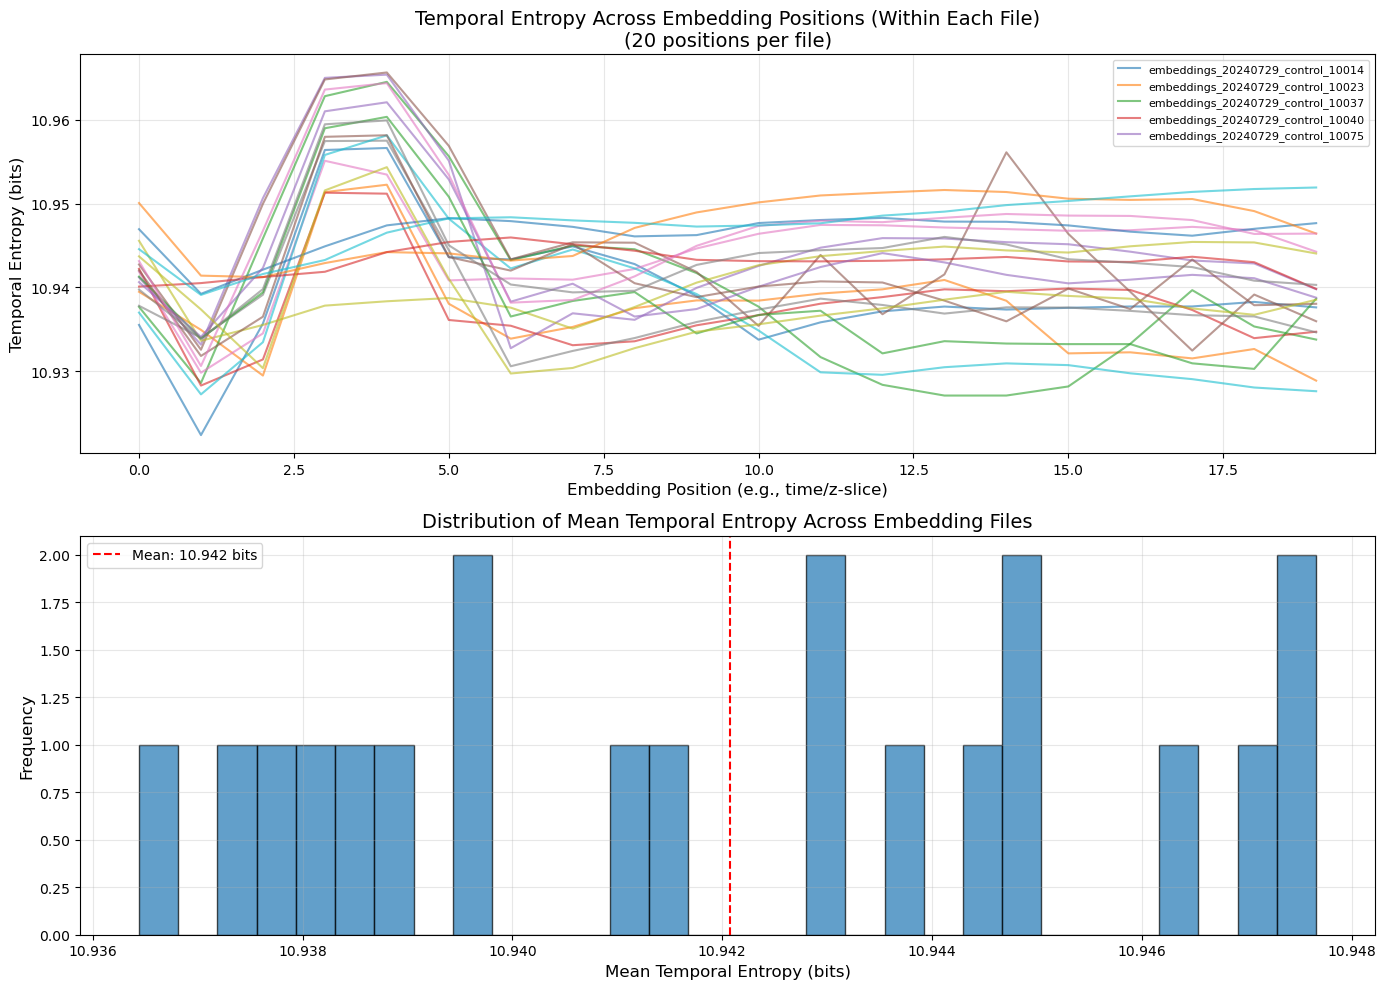


Temporal Entropy Statistics (in embedding space):
  Number of files processed: 20
  Embedding positions per file: 20
  Embedding dimension: 2048
  Mean entropy (across all positions and files): 10.9421 bits
  Std (across files): 0.0036 bits
  Min mean entropy: 10.9364 bits
  Max mean entropy: 10.9477 bits


(<Figure size 1400x1000 with 2 Axes>,
 [array([10.93551548, 10.92236569, 10.93567783, 10.9563928 , 10.95662876,
         10.94359591, 10.94333037, 10.94488785, 10.94277452, 10.93895926,
         10.93375163, 10.93582298, 10.93713693, 10.93770447, 10.93734675,
         10.93755588, 10.93771548, 10.93771823, 10.93825688, 10.93760541]),
  array([10.93946764, 10.93492523, 10.92947201, 10.95135921, 10.95224664,
         10.93804018, 10.9338727 , 10.93527333, 10.93751185, 10.9384385 ,
         10.93841442, 10.93925645, 10.93976001, 10.94087859, 10.93839791,
         10.93211779, 10.93224437, 10.9315186 , 10.93264062, 10.92886457]),
  array([10.93766595, 10.92858802, 10.94583237, 10.96281394, 10.96452001,
         10.95564846, 10.94324163, 10.9449814 , 10.94454388, 10.94170273,
         10.93769484, 10.93167545, 10.92836375, 10.9270842 , 10.92708627,
         10.92816976, 10.93325769, 10.9396637 , 10.93532561, 10.93376607]),
  array([10.94221042, 10.92827845, 10.9313934 , 10.95129386, 10.9511

In [17]:

# Plot spatial entropy (between embeddings)


# plot_spatial_entropy(metrics, embeddings_dir=embeddings_dir, 
#                      save_path="spatial_entropy_plot.png")

# Plot temporal entropy in embedding space (within embeddings)
# This computes entropy across embedding dimensions for each of the 60 embedding positions
plot_temporal_entropy_in_embedding_space(embeddings_dir=embeddings_dir,
                                         save_path="temporal_entropy_embedding_space.png", 
                                         max_files=20)
